In [14]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import textgrids
from pathlib import Path
import re

In [15]:
def get_words(txt_dir, align_type="words"):
    tg_files = list(Path(txt_dir).rglob("*.TextGrid"))
    text = []

    for tg_path in tg_files:
        tg = textgrids.TextGrid(str(tg_path))
        tier = tg[align_type]

        for interval in tier:
            label = interval.text.strip().lower()
            if label in ["", "<unk>", "sp", "sil", "spn"]:
                continue
            #  remove numbers and decimals
            label = re.sub(r'\d+', '', label)
            text.append(label)
    
    if align_type == "phones":
        text = [re.sub(r'\d+', '', phn) for phn in text]

    return text

def get_clusters(partition_path):
    clusters = []
    current_cluster = []
    
    with open(partition_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) == 3:
                current_cluster.append(tuple(parts))
            
            elif len(parts) == 2 and current_cluster:
                clusters.append(current_cluster)
                current_cluster = [] 
                
        if current_cluster:
            clusters.append(current_cluster)

    return clusters

In [16]:
align_dir = Path("../data/alignments/LibriSpeech/dev-clean_feature_sliced")
partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fbgmm/")

k='4,473'
dataset = partition_dir.parts[1]
dataset_subset = "-".join(partition_dir.parts[2].split("_"))

boundary_info_total = "".join(partition_dir.parts[3:])
if "norm-prom-seg" in boundary_info_total:
    if "prominence_0.35_window_3" in boundary_info_total:
        boundary_info = "ZeroSyl"
    else:
        boundary_info = "Prominence-based"
elif "gt" in boundary_info_total:
    boundary_info = "Ground Truth"
    if "words" in boundary_info_total:
        boundary_info += " Words"
    elif "syllables" in boundary_info_total:
        boundary_info += " syllables"
print(f"Dataset: {dataset}")
print(f"Info: {boundary_info}")

align_type = "words"
words = get_words(align_dir, align_type)
print(f"Total {align_type}: {len(words):,}")

Dataset: LibriSpeech
Info: Ground Truth Words
Total words: 54,402


In [17]:
def get_data_label(stem, k=None):
    if "knn" in stem:
        k_n = stem.split('_')[2].split('k')[1]
        threshold = float(stem.split('_')[3].split('t')[1])
        resolution = float(stem.split('_')[4].split('r')[1])
        if k is not None:
            print(f"Extracted k: {k_n}")
            print(f"Extracted threshold: {threshold}")
            print(f"Extracted resolution: {resolution}")
            return f"Graph (knn, {k_n}) ($k$={k:,}, $\\tau$={1-threshold:<.2f})"
        return f"Graph (knn) ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
    if "cosine" in stem:
        threshold = float(stem.split('_')[1].split('t')[1])
        resolution = float(stem.split('_')[2].split('r')[1])
        if k is not None:
            return f"Graph (cos) ($k$={k:,}, $\\tau$={1-threshold:<.2f}, $\\gamma$={resolution:<.2f})"
        return f"Graph (cos) ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
    elif "edit" in stem and "lsh" in stem:
        threshold = float(stem.split('_')[1].split('t')[1])
        resolution = float(stem.split('_')[3].split('r')[1])
        if k is not None:
            return f"Graph (edit LSH) ($k$={k:,}, $\\tau$={1-threshold:<.2f})"
        return f"Graph (edit) LSH ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
    elif "edit" in stem:
        threshold = float(stem.split('_')[1].split('t')[1])
        resolution = float(stem.split('_')[2].split('r')[1])
        if k is not None:
            return f"Graph (edit) ($k$={k:,}, $\\tau$={1-threshold:<.2f})"
        return f"Graph (edit) ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
    elif "kmeans" in stem:
        if k is not None:
            return f"K-means ($k$={k:,})"
        return f"K-means"  
    elif "agglomerative" in stem:
        if k is not None:
            return f"Agglomerative Clustering ($k$={k:,})"
        return f"Agglomerative Clustering"
    elif "fbgmm" in stem:
        iter = extract_iter(Path(stem))
        s0 = extract_s0(Path(stem))
        k0 = float(stem.split('_')[4].split('KO')[1])
        each_own = "each-in-own" in stem
        if k is not None:
            return f"Bayesian GMM ($k$={k:,}, iter={iter}, $s_0$={s0}, $k_0$={k0})" if not each_own else f"Bayesian GMM ($k$={k:,}, iter={iter}, $s_0$={s0}, $k_0$={k0}, each)"
        return f"Bayesian GMM (iter={iter}, $s_0$={s0}, $k_0$={k0})" if not each_own else f"Bayesian GMM (iter={iter}, $s_0$={s0}, $k_0$={k0}, each)"
    elif "gmm" in stem:
        if k is not None:
            return f"GMM ($k$={k:,})"
        return f"GMM ($s_0$={s0})"
    elif "birch" in stem:
        if k is not None:
            return f"Birch ($k$={k:,})"
        return f"Birch"

def extract_threshold(path):
    if "t0" in path.stem:
        threshold = f'0{path.stem.split("t0")[1].split("_")[0]}'
        threshold = float(threshold)
    else:
        threshold = np.inf
    return float(threshold)

def extract_resolution(path):
    if "r" in path.stem:
        resolution = f'0{path.stem.split("r0")[1].split("_")[0]}'
        resolution = float(resolution)
    else:
        resolution = np.inf
    return float(resolution)
   
def extract_k(path):    
    if "k" in path.stem:
        k = path.stem.split("_")[1].split("k")[1]
        k = int(k.replace(",", ""))
    else:
        k = np.inf
    return k

def extract_iter(path):
    if "iter" in path.stem:
        n_iter = path.stem.split("iter")[1].split("_")[0]
        n_iter = int(n_iter)
    else:
        n_iter = np.inf
    return n_iter

def extract_s0(path):
    if "SO" in path.stem:
        s_0 = path.stem.split("SO")[1].split("_")[0]
        s_0 = float(s_0)
    else:
        s_0 = np.inf
    return s_0


<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_45927/2929016260.py:11: SyntaxWarning: invalid escape sequence '\g'
  return f"Graph (knn) ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
/tmp/ipykernel_45927/2929016260.py:17: SyntaxWarning: invalid escape sequence '\g'
  return f"Graph (cos) ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
/tmp/ipykernel_45927/2929016260.py:23: SyntaxWarning: invalid escape sequence '\g'
  return f"Graph (edit) LSH ($\\tau$={1-threshold:<.2f}, $\gamma$={resolution:<.2f})"
/tmp/ipykernel_45927/2929016260.py:29: SyntaxWarning: invalid escape sequence '\g'
  return f"G

# Distribution on a Log-log plot

kmeans_k8372_269.82: 8,372 clusters
agglomerative_k8372_522.84_13402.23_avg: 8,372 clusters
fbgmm_k8372_iter1_alpha1.0_KO0.05_SO0.1_858.60_fixed: 8,372 clusters
fbgmm_k9050_iter5_alpha1.0_KO0.05_SO0.3_14514.09_fixed_each-in-own: 9,050 clusters
fbgmm_k9207_iter1_alpha1.0_KO0.05_SO0.5_4460.66_fixed_each-in-own: 9,207 clusters
cosine_t0.7_r0.5501_248.49: 8,372 clusters


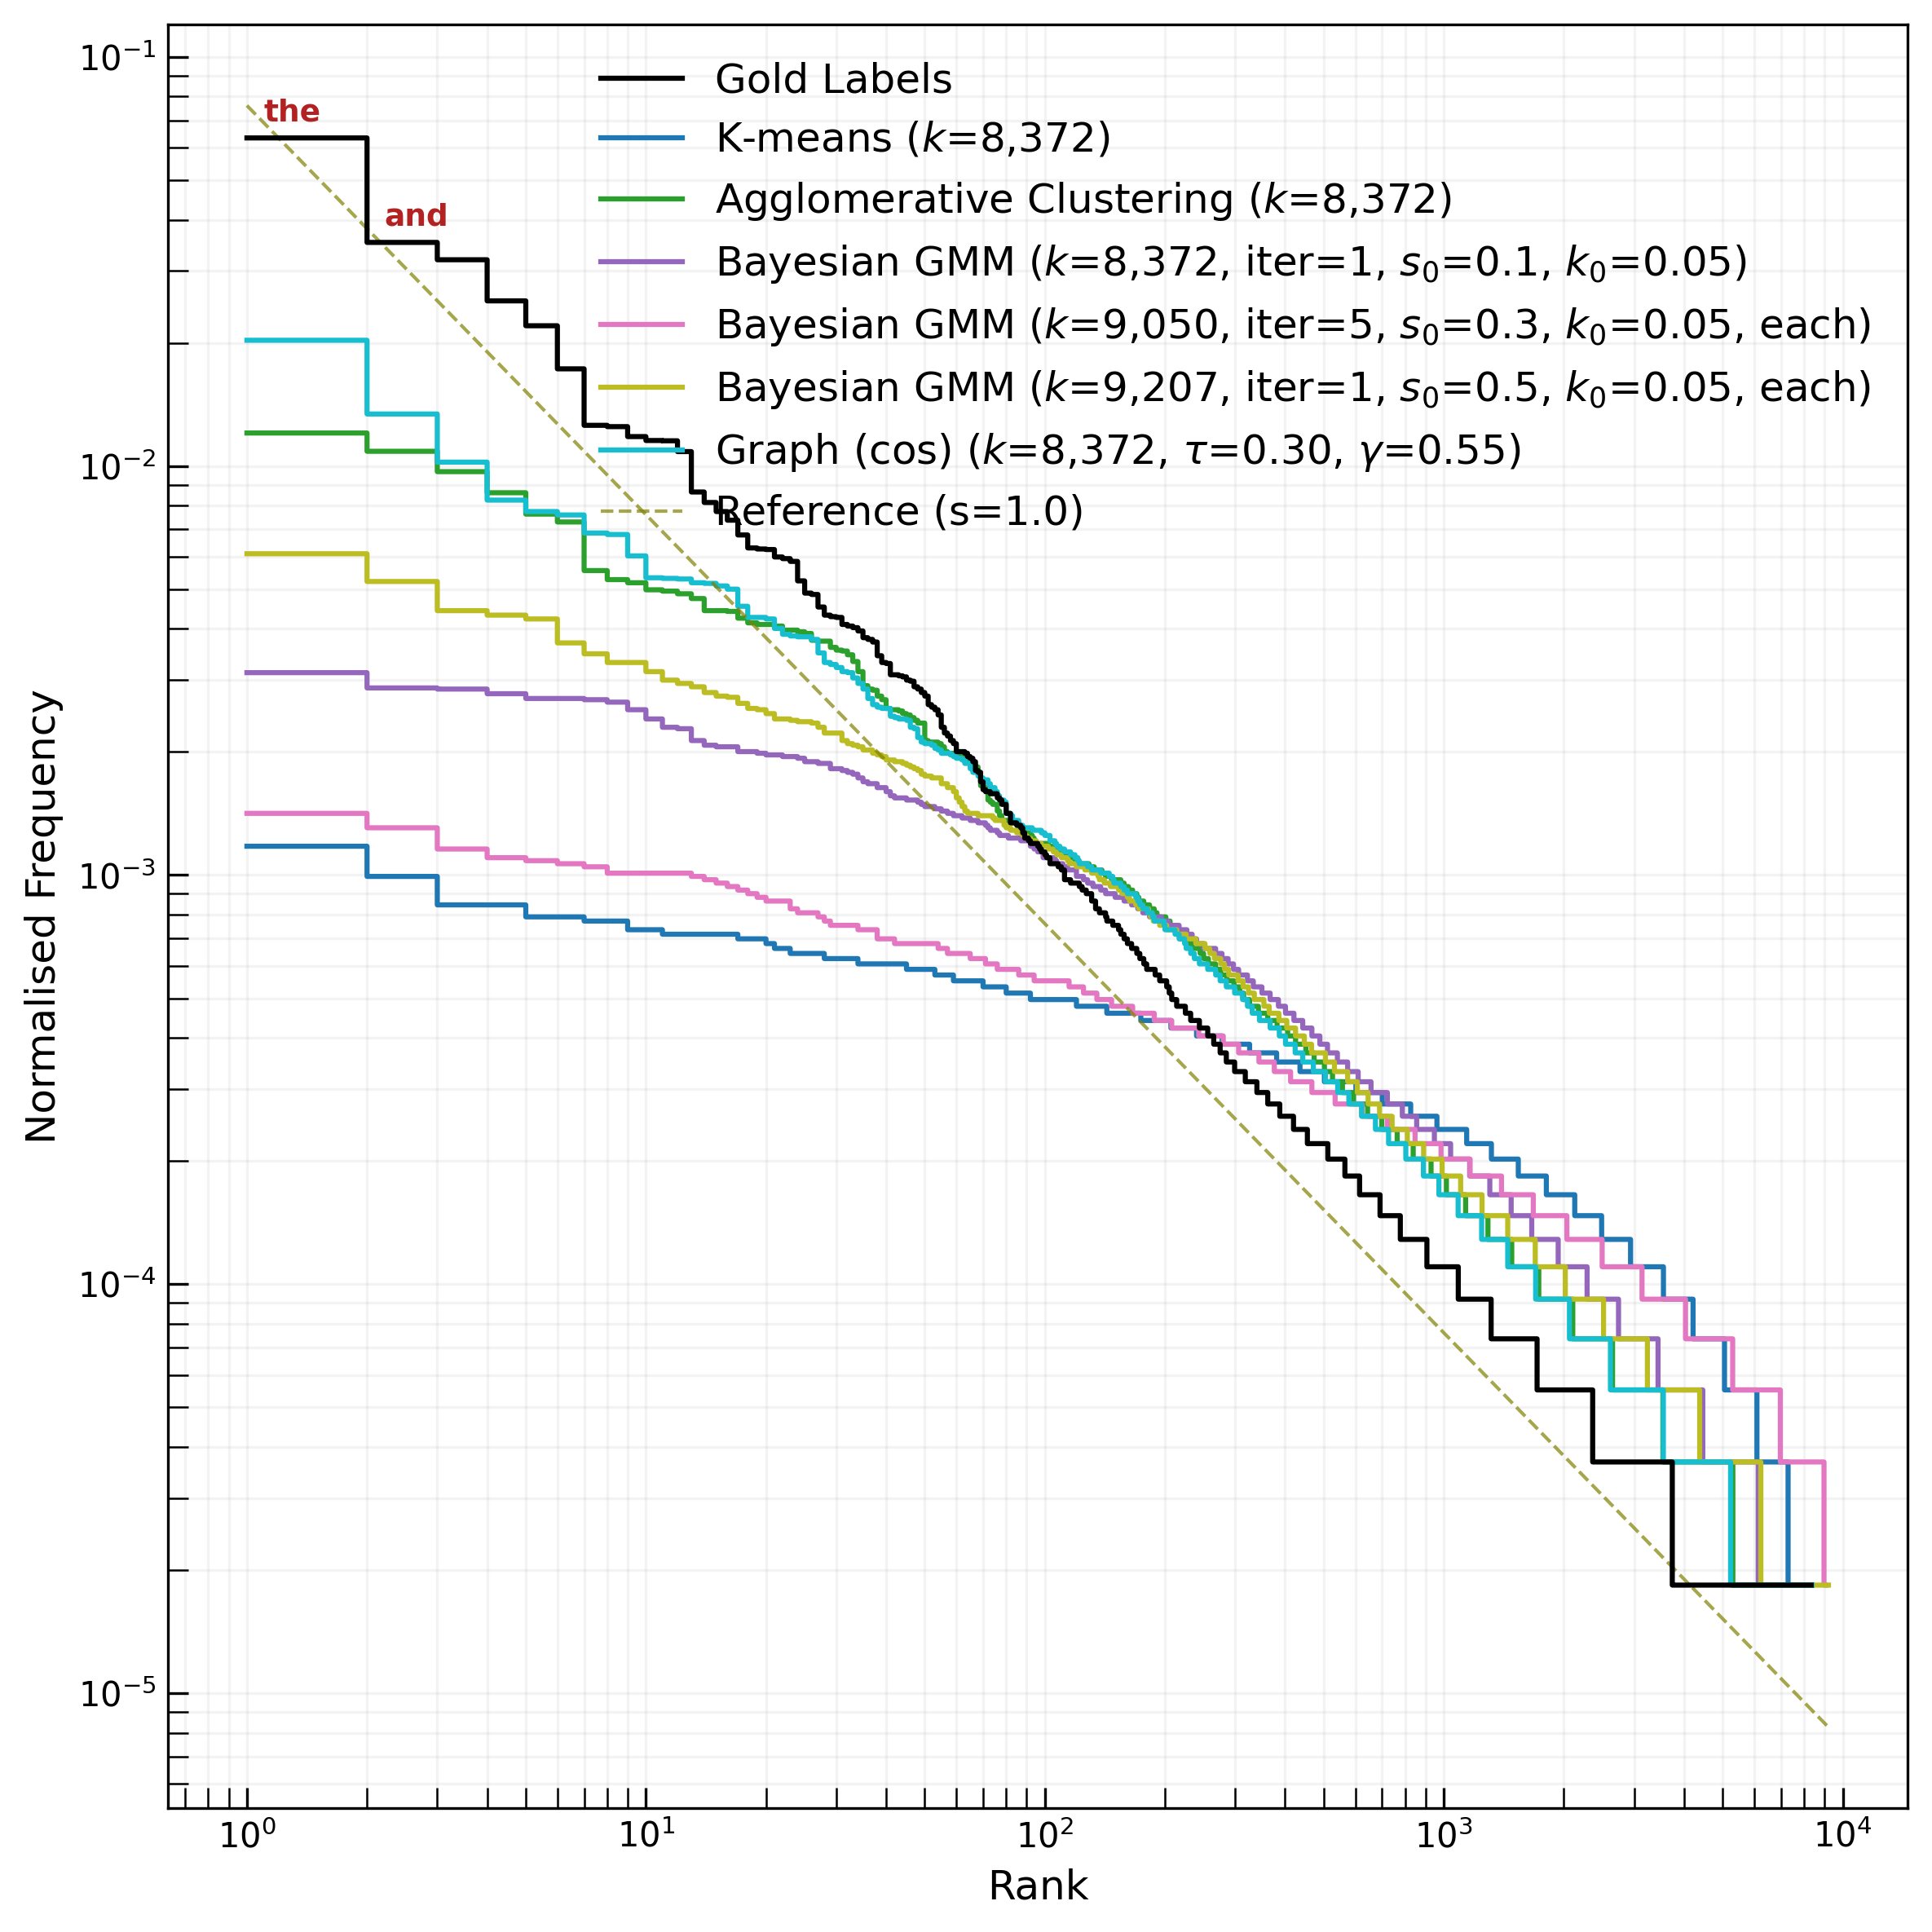

In [5]:
paths = sorted(partition_dir.glob("*.txt"), key=extract_k)

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
num_paths = len(paths)

color_map = plt.get_cmap('tab10', num_paths)

def get_color(stem):
    if "knn" in stem:
        return color_map(10)
    elif "edit" in stem:
        return color_map(3)
    elif "cosine" in stem:
        return color_map(0)
    elif "kmeans" in stem:
        return color_map(7)
    elif "agglomerative" in stem:
        return color_map(2)
    elif "fbgmm" in stem:
        return color_map(1)
    elif "gmm" in stem:
        return color_map(1)
    else:
        return color_map(1)

word_counts = Counter(words)
gold_unique_tokens, w_counts = zip(*word_counts.most_common())
tokens, counts = zip(*word_counts.most_common())

n_samples = 20
indices = np.unique(np.round(np.logspace(0, np.log10(len(tokens)-1), n_samples)).astype(int))

w_counts_norm = np.array(w_counts) / sum(w_counts)
w_ranks = np.arange(1, len(w_counts_norm) + 1)

ax.loglog(w_ranks, w_counts_norm, linestyle='-', color='black', 
            linewidth=1.5, drawstyle='steps-post', label='Gold Labels', zorder=3)

for i in range(min(2, len(gold_unique_tokens))):
    ax.annotate(gold_unique_tokens[i], 
                (w_ranks[i], w_counts_norm[i]), 
                textcoords="offset points", 
                xytext=(5, 5), 
                ha='left', 
                fontsize=9,  
                fontweight='bold',
                color='firebrick',)

global_max_freq = 0
global_max_rank = 0

for i, path in enumerate(paths):
    if "knn" in path.stem or "edit" in path.stem:
        continue
    
    clusters = get_clusters(path) 
    print(f"{path.stem}: {len(clusters):,} clusters")
    try:
        data_label = get_data_label(path.stem, k=len(clusters))
    except NameError:
        data_label = "Empirical"
    counts = sorted([len(c) for c in clusters], reverse=True)
    counts_norm = np.array(counts) / sum(counts)
    ranks = np.arange(1, len(counts) + 1)
    
    global_max_freq = max(global_max_freq, counts_norm[0])
    global_max_rank = max(global_max_rank, len(counts))
    ax.loglog(ranks, counts_norm, label=data_label, color=color_map(i), 
                linewidth=1.5, drawstyle='steps-post')
    indices = np.unique(
        np.round(np.logspace(0, np.log10(len(counts) - 1), n_samples)).astype(int)
    )

            
global_max_freq = max(global_max_freq, w_counts_norm[0])
global_max_rank = max(global_max_rank, len(w_counts_norm))

ref_ranks = np.logspace(0, np.log10(global_max_rank), 100)
ref_counts = (global_max_freq * 1.2) / (ref_ranks**1.0)

ax.loglog(ref_ranks, ref_counts, linestyle='--', color='olive', 
            alpha=0.7, linewidth=1, label='Reference (s=1.0)')

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Normalised Frequency', fontsize=12)

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction='in', which='both', length=6)
ax.legend(frameon=False, fontsize=12)

plt.tight_layout()

fig_dir = Path("figs") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)

safe_boundary_info = "_".join(str(boundary_info).split())

# plt.savefig(
#     fig_dir / f"zipf_plot_{dataset_subset}_{safe_boundary_info}.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

In [18]:
def get_words(txt_dir, align_type="words"):
    tg_files = list(Path(txt_dir).rglob("*.TextGrid"))
    text = []

    for tg_path in tg_files:
        tg = textgrids.TextGrid(str(tg_path))
        tier = tg[align_type]

        for interval in tier:
            label = interval.text.strip().lower()
            if label in ["", "<unk>", "sp", "sil", "spn"]:
                continue
            #  remove numbers and decimals
            label = re.sub(r'\d+', '', label)
            text.append(label)
    
    if align_type == "phones":
        text = [re.sub(r'\d+', '', phn) for phn in text]

    return text

def get_clusters(partition_path):
    clusters = []
    current_cluster = []
    
    with open(partition_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) == 3:
                current_cluster.append(tuple(parts))
            
            elif len(parts) == 2 and current_cluster:
                clusters.append(current_cluster)
                current_cluster = [] 
                
        if current_cluster:
            clusters.append(current_cluster)

    return clusters

findfont: Font family 'STIXTwo Text' not found.
findfont: Font family ['STIXTwo Text'] not found. Falling back to DejaVu Sans.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont: Font family 'STIXTwo Text' not found.
findfont:

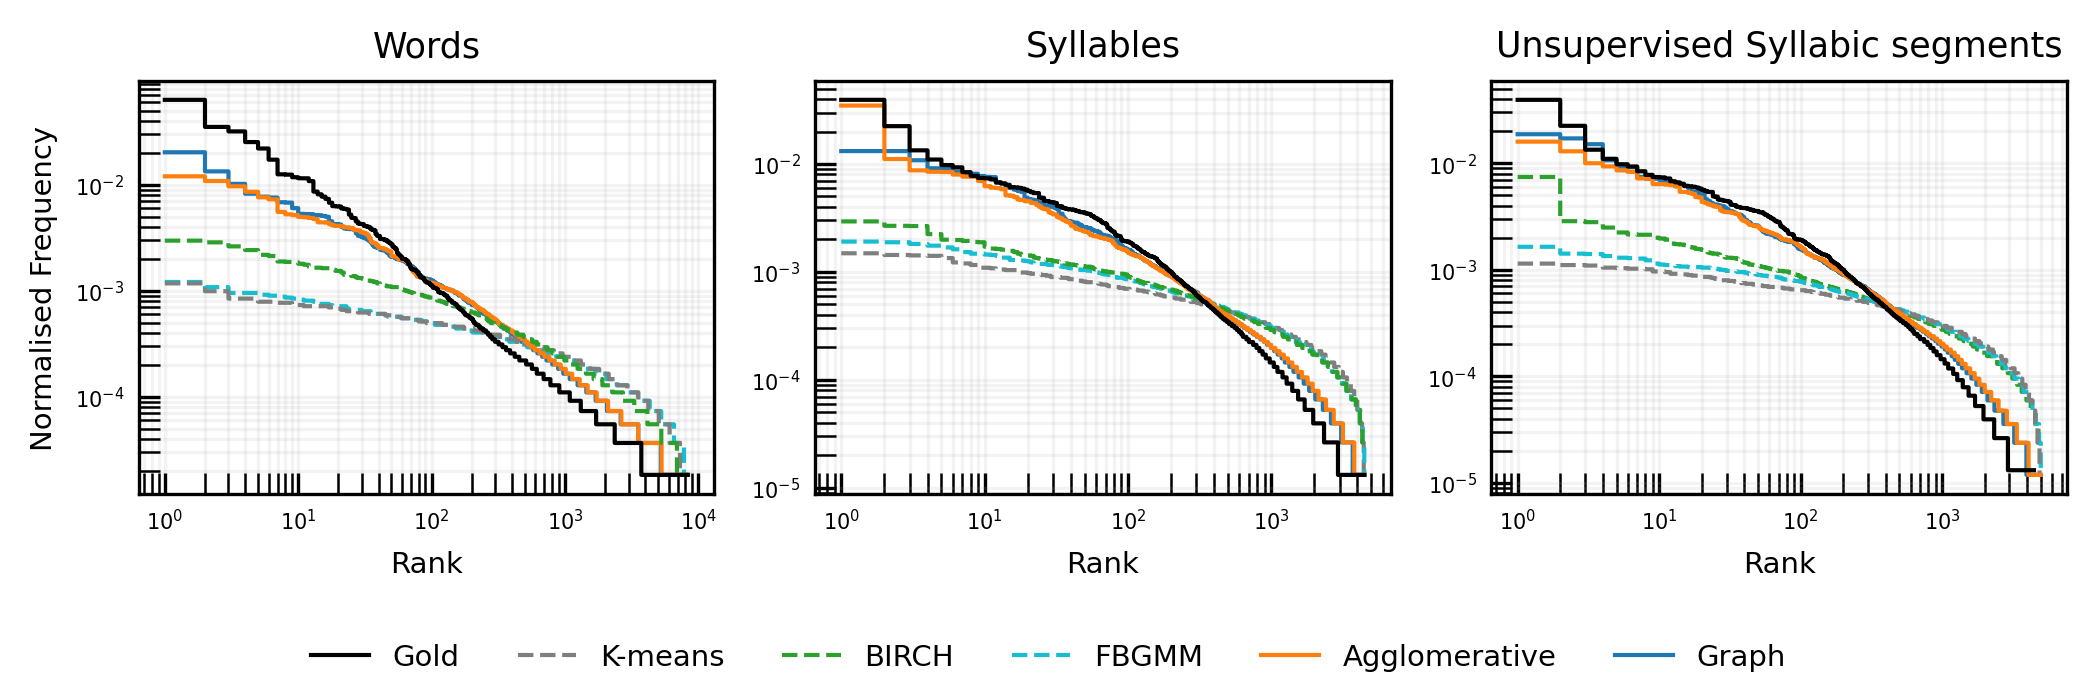

In [20]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "STIXTwo Text",
    "font.size": 7,
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

words_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fig")
syllables_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/syllables/fig")
syllabic_segments_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/norm-prom-seg/prominence_0.35_window_3/k5_000")

dataset_dir = Path("../data/alignments/LibriSpeech/dev-clean_feature_sliced/")
gt_words = get_words(dataset_dir, align_type="words")
gt_syllables = get_words(dataset_dir, align_type="syllables")
gt_syllabic_segments = get_words(dataset_dir, align_type="syllables")

dataset = words_partition_dir.parts[1]
dataset_subset = words_partition_dir.parts[2].split("_")[0]
fig_dir = Path("figs") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)

partition_dirs = [
    words_partition_dir,
    syllables_partition_dir,
    syllabic_segments_partition_dir,
]

gt_words_list = [
    gt_words,
    gt_syllables,
    gt_syllabic_segments,
]

subplot_titles = [
    "Words",
    "Syllables",
    "Unsupervised Syllabic segments",
]

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4), dpi=300, sharey=False)

legend_handles = {}
n_samples = 20

def get_color(stem):
    if "cosine" in stem:
        return "tab:blue"
    elif "kmeans" in stem:
        return "tab:gray"
    elif "birch" in stem:
        return "tab:green"
    elif "agglomerative" in stem:
        return "tab:orange"
    elif "fbgmm" in stem:
        return "tab:cyan"
    else:
        return "tab:green"
    
def method_label(stem):
    stem = stem.lower()
    if "kmeans" in stem:
        return "K-means"
    elif "birch" in stem:
        return "BIRCH"
    elif "agglomerative" in stem:
        return "Agglomerative"
    elif "cosine" in stem or "graph" in stem:
        return "Graph"
    elif "fbgmm" in stem:
        return "FBGMM"
    else:
        return None

LINESTYLE = {
    "K-means":      "--",
    "BIRCH":        "--",
    "FBGMM":        "--",
    "Agglomerative": "-",
    "Graph":         "-",
}

for ax, partition_dir, gt_items, title in zip(
    axes, partition_dirs, gt_words_list, subplot_titles
):
    paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

    # Ground truth
    gt_counts = Counter(gt_items)
    gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
    gt_probs = gt_freqs / gt_freqs.sum()
    gt_ranks = np.arange(1, len(gt_probs) + 1)

    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        linestyle="-",
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Ground truth",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)

    global_max_freq = gt_probs[0]
    global_max_rank = len(gt_probs)

    # Partitions
    for path in paths:
        if "knn" in path.stem or "edit" in path.stem:
            continue

        label = method_label(path.stem)
        if label is None:
            continue

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)


        line, = ax.loglog(
            ranks,
            probs,
            label=label,
            color={
                "K-means": "tab:gray",
                "Agglomerative": "tab:orange",
                "Graph": "tab:blue",
                "BIRCH": "tab:green",
                "FBGMM": "tab:cyan",
            }[label],
            linestyle=LINESTYLE[label],  
            linewidth=1,
            drawstyle="steps-post",
        )

        legend_handles.setdefault(label, line)

        global_max_freq = max(global_max_freq, probs[0])
        global_max_rank = max(global_max_rank, len(probs))

    
    ax.set_title(title)
    ax.set_xlabel("Rank")
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[0].set_ylabel("Normalised Frequency")

legend_order = ["Gold", "K-means","BIRCH", "FBGMM", "Agglomerative", "Graph"]

fig.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="lower center",
    ncol=6,
    frameon=False,
)

# fig.suptitle(f"{dataset_subset.capitalize()}", fontsize=13)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])

plt.savefig(
    fig_dir / f"zipf_plot_{dataset_subset}.pdf",
    bbox_inches="tight",
)
plt.show()

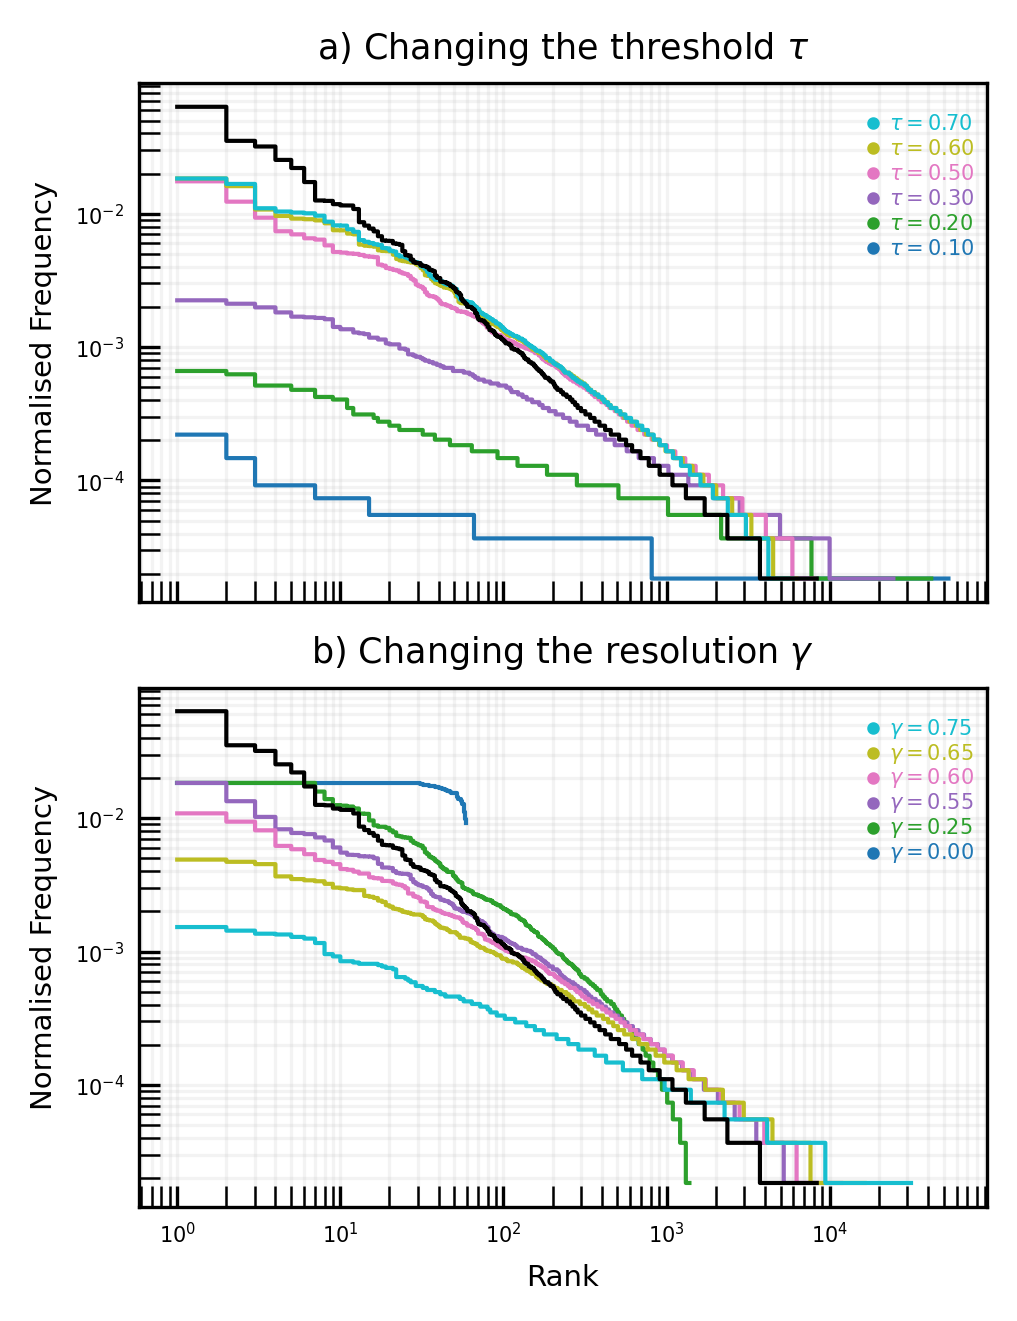

In [6]:
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

fig_dir = Path("figs") / dataset / dataset_subset

tau_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/r0.5/fig")
gamma_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/t0.7")

plot_configs = [
    {
        "partition_dir": tau_partition_dir,
        "title": r"a) Changing the threshold $\tau$",
        "parameter_name": "tau",
    },
    {
        "partition_dir": gamma_partition_dir,
        "title": r"b) Changing the resolution $\gamma$",
        "parameter_name": "gamma",
    },
]

gt_items = gt_words

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 4.8),
    dpi=300,
    sharex=True,
    sharey=True
)

legend_handles = {}

# Ground-truth distribution, same for both plots
gt_counts = Counter(gt_items)
gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
gt_probs = gt_freqs / gt_freqs.sum()
gt_ranks = np.arange(1, len(gt_probs) + 1)

for ax, config in zip(axes, plot_configs):
    labels = []

    partition_dir = config["partition_dir"]
    title = config["title"]
    parameter_name = config["parameter_name"]

    if parameter_name == "tau":
        paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)
    else:
        paths = sorted(partition_dir.glob("*.txt"), key=extract_resolution)

    # Gold line
    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        linestyle="-",
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Gold",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)
    color_map = plt.get_cmap("tab10", len(paths))
    
    for i, path in enumerate(paths):

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)

        color = color_map(i)

        if parameter_name == "tau":
            value = extract_threshold(path)
            label_text = rf"$\tau={value:.2f}$"
        else:
            value = extract_resolution(path)
            label_text = rf"$\gamma={value:.2f}$"

        line, = ax.loglog(
            ranks,
            probs,
            color=color,
            linewidth=1,
            drawstyle="steps-post",
            label="Graph",
        )

        legend_handles.setdefault("Graph", line)

        # Direct label on each curve
        label_idx = int(len(ranks) * 0.8)

        labels.append((label_text, color))

    labels = sorted(labels, reverse=True)
    x_label_pos = ax.get_xlim()[1] * 0.25

    y_start = ax.get_ylim()[1] * 0.5
    y_factor = 0.65  

    for label_text, color in labels:
        ax.plot(
            x_label_pos * 0.8,
            y_start,
            marker="o",
            markersize=2,
            color=color,
            clip_on=False,
        )
        ax.text(
            x_label_pos,
            y_start,
            label_text,
            fontsize=5,
            color=color,
            ha="left",
            va="center",
            clip_on=False,
        )
        y_start *= y_factor

    ax.set_title(title)
    ax.set_ylabel("Normalised Frequency")
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[-1].set_xlabel("Rank")

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    fig_dir / f"zipf_plot_tau_gamma_{dataset_subset}.pdf",
    bbox_inches="tight",
)

plt.show()

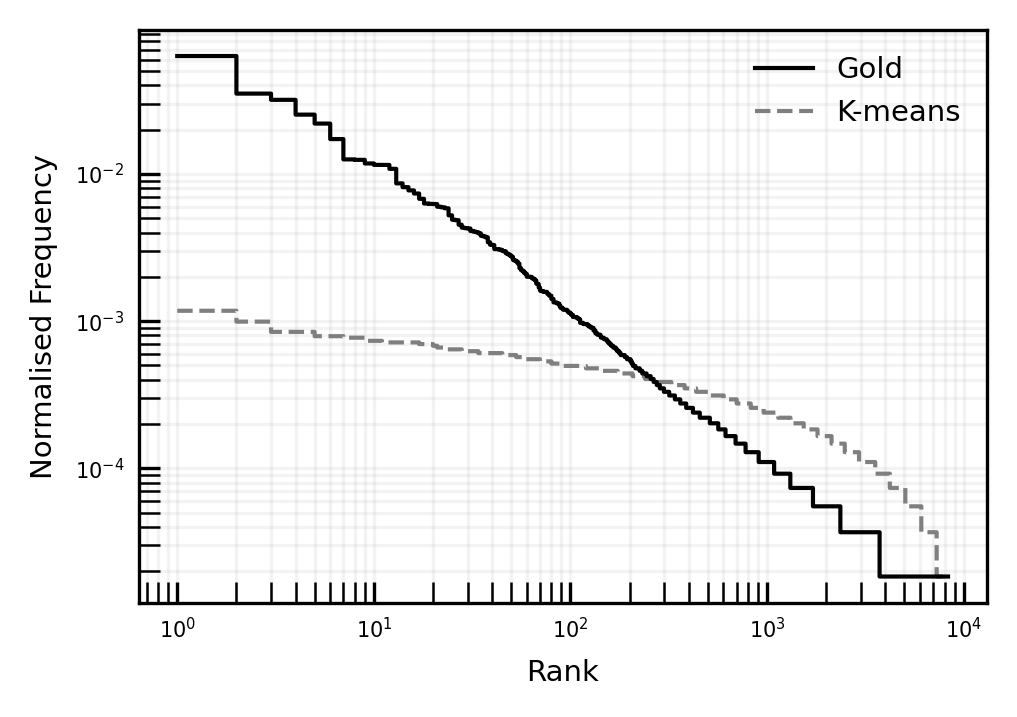

In [12]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fbgmm")

dataset_dir = Path("../data/alignments/LibriSpeech/dev-clean_feature_sliced/")
gt_items = get_words(dataset_dir, align_type="words")

dataset = partition_dir.parts[1]
dataset_subset = partition_dir.parts[2].split("_")[0]
fig_dir = Path("figs") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)

legend_handles = {}

def method_label(stem):
    stem = stem.lower()
    if "kmeans" in stem:
        return "K-means"
    elif "birch" in stem:
        return "Birch"
    elif "cosine" in stem or "graph" in stem:
        return "Graph"
    elif "fbgmm" in stem:
        return "FBGMM"
    elif "gmm" in stem:
        return "GMM"
    else:
        return None

# Ground truth
gt_counts = Counter(gt_items)
gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
gt_probs = gt_freqs / gt_freqs.sum()
gt_ranks = np.arange(1, len(gt_probs) + 1)

line, = ax.loglog(
    gt_ranks,
    gt_probs,
    linestyle="-",
    color="black",
    linewidth=1,
    drawstyle="steps-post",
    label="Ground truth",
    zorder=3,
)
legend_handles.setdefault("Gold", line)

global_max_freq = gt_probs[0]
global_max_rank = len(gt_probs)

# Partitions
paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

for path in paths:
    if "kmeans" not in path.stem:
        continue
    label = method_label(path.stem)
    if label is None:
        continue

    clusters = get_clusters(path)
    cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
    probs = cluster_sizes / cluster_sizes.sum()
    ranks = np.arange(1, len(probs) + 1)

    line, = ax.loglog(
        ranks,
        probs,
        label=label,
        color={
            "K-means": "tab:gray",
            "Birch": "tab:green",
            "Graph": "tab:blue",
            "GMM" : "tab:orange",
            "FBGMM": "tab:purple",
        }[label],
        linewidth=1,
        drawstyle="steps-post",
        linestyle=LINESTYLE[label],
    )

    legend_handles.setdefault(label, line)

    global_max_freq = max(global_max_freq, probs[0])
    global_max_rank = max(global_max_rank, len(probs))

# Zipf reference line
# ref_ranks = np.logspace(0, np.log10(global_max_rank), 100)
# ref_probs = (global_max_freq * 1.2) / ref_ranks

# line, = ax.loglog(
#     ref_ranks,
#     ref_probs,
#     linestyle="--",
#     color="olive",
#     alpha=0.7,
#     linewidth=1,
#     label="Reference (s=1.0)",
# )
# legend_handles.setdefault("Ref (s=1.0)", line)

# ax.set_title("Words")
ax.set_xlabel("Rank")
ax.set_ylabel("Normalised Frequency")
ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

legend_order = ["Ref (s=1.0)", "Gold", "K-means", "Birch", "Graph", "GMM", "FBGMM"]

ax.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="best",
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    fig_dir / f"zipf_plot_words_{dataset_subset}.pdf",
    bbox_inches="tight",
)

plt.show()

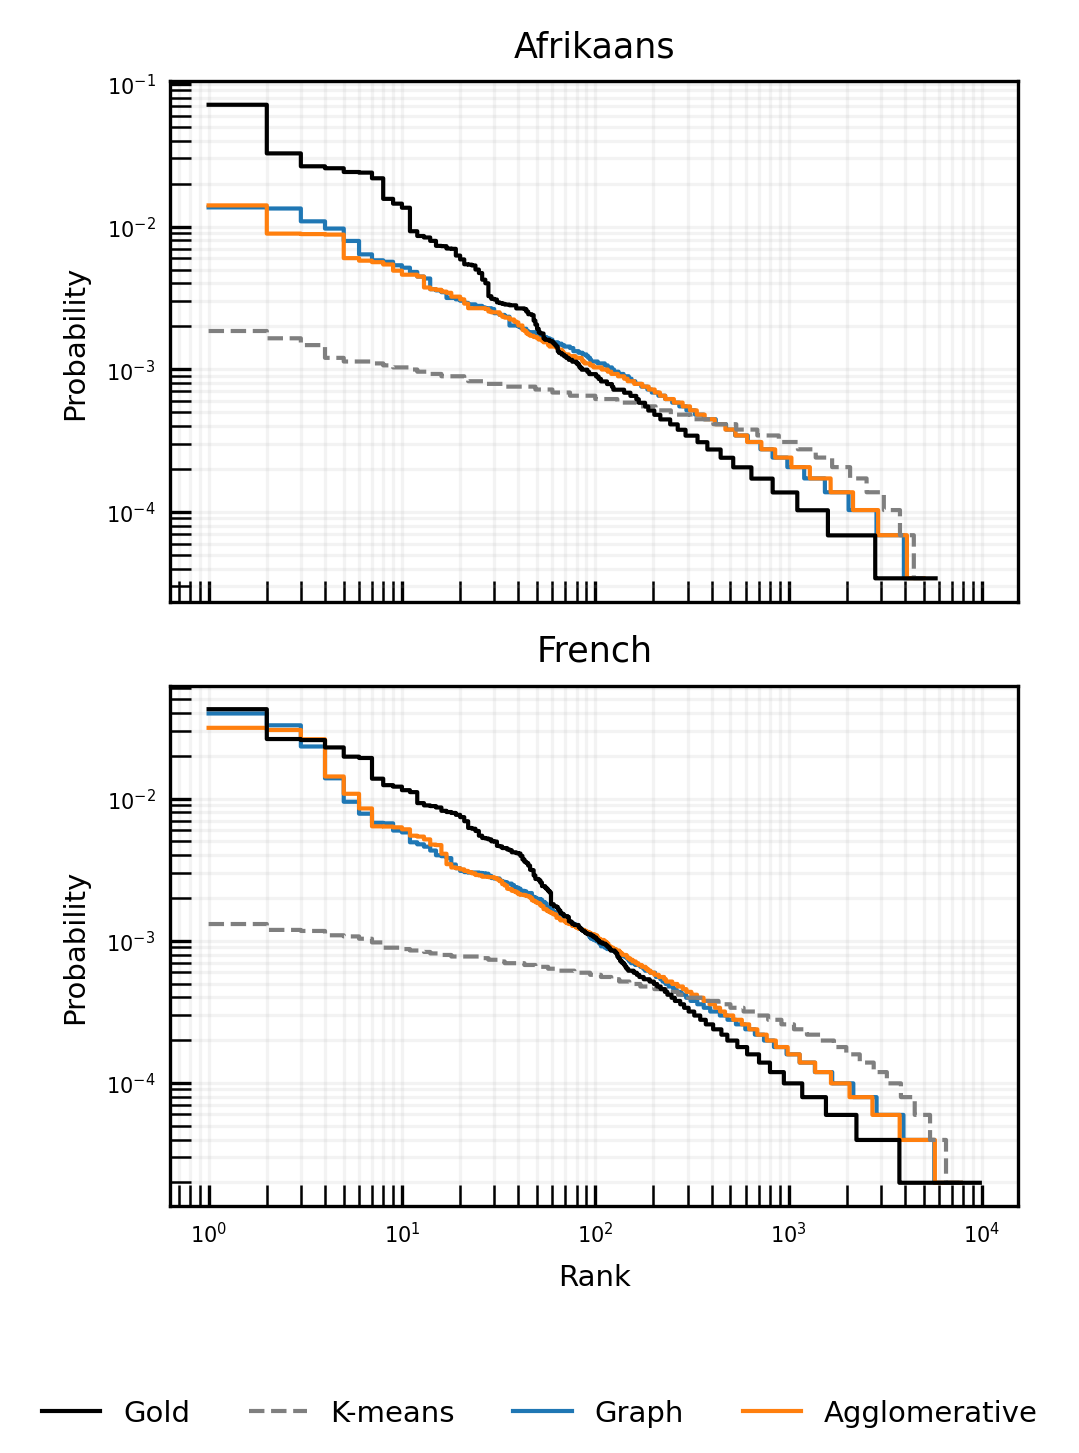

In [11]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

language_configs = [
    {
        "title": "Afrikaans",
        "partition_dir": Path("outputs/Fleurs/afrikaans_feature_sliced/wavlm_large/layer_21/gt/words/fig"),
        "dataset_dir": Path("../data/alignments/Fleurs/afrikaans_sliced_with_syllables/"),
        "align_type": "words",
    },
    {
        "title": "French",
        "partition_dir": Path("outputs/zerospeech/french_subset2/wavlm_large/layer_21/gt/words/fig"),
        "dataset_dir": Path("../data/alignments/zerospeech/french_feature_sliced_with_syllables_subset2_with_syllables/"),
        "align_type": "words",
    },
]

fig_dir = Path("figs/word_level_language_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

def method_label(stem):
    stem = stem.lower()
    if "kmeans" in stem:
        return "K-means"
    elif "cosine" in stem or "graph" in stem:
        return "Graph"
    elif "agglomerative" in stem:
        return "Agglomerative"
    else:
        return None

colors = {
    "Gold": "black",
    "K-means": "tab:gray",
    "Graph": "tab:blue",
    "Agglomerative": "tab:orange",
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 4.8),
    dpi=300,
    sharex=True,
    sharey=False,
)

legend_handles = {}

for ax, config in zip(axes, language_configs):

    partition_dir = config["partition_dir"]
    gt_words = get_words(config["dataset_dir"], align_type=config["align_type"])

    paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

    # Gold distribution
    gt_counts = Counter(gt_words)
    gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
    gt_probs = gt_freqs / gt_freqs.sum()
    gt_ranks = np.arange(1, len(gt_probs) + 1)

    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        color=colors["Gold"],
        linewidth=1,
        drawstyle="steps-post",
        label="Gold",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)

    # Cluster distributions
    for path in paths:
        label = method_label(path.stem)

        if label is None:
            continue

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)

        line, = ax.loglog(
            ranks,
            probs,
            color=colors[label],
            linewidth=1,
            linestyle=LINESTYLE[label],
            drawstyle="steps-post",
            label=label,
        )

        legend_handles.setdefault(label, line)
    ref_ranks = np.logspace(0, np.log10(global_max_rank), 100)
    ref_probs = (global_max_freq * 1.2) / ref_ranks

    ax.set_title(config["title"])
    ax.set_ylabel("Probability") 
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[-1].set_xlabel("Rank")

legend_order = ["Gold", "K-means", "Graph", "Agglomerative"]

fig.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="lower center",
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    Path("figs") / "zipf_word_level_two_languages.pdf",
    bbox_inches="tight",
)

plt.show()